In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv("D:\Apple_stock_price_prediction\P587 DATASET.csv")
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df = df.sort_values('Date')
df.set_index('Date', inplace=True)
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\Dell\AppData\Local\Temp\ipykernel_12944\1070281796.py:1: SyntaxWarning: invalid escape sequence '\A'
  df = pd.read_csv("D:\Apple_stock_price_prediction\P587 DATASET.csv")


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


In [44]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [45]:
df.describe

<bound method NDFrame.describe of                   Open        High         Low       Close   Adj Close  \
Date                                                                     
2012-01-03   58.485714   58.928570   58.428570   58.747143   50.765709   
2012-01-04   58.571430   59.240002   58.468571   59.062859   51.038536   
2012-01-05   59.278572   59.792858   58.952858   59.718571   51.605175   
2012-01-06   59.967144   60.392857   59.888573   60.342857   52.144630   
2012-01-09   60.785713   61.107143   60.192856   60.247143   52.061932   
...                ...         ...         ...         ...         ...   
2019-12-23  280.529999  284.250000  280.369995  284.000000  282.054138   
2019-12-24  284.690002  284.890015  282.920013  284.269989  282.322266   
2019-12-26  284.820007  289.980011  284.700012  289.910004  287.923645   
2019-12-27  291.119995  293.970001  288.119995  289.799988  287.814392   
2019-12-30  289.459991  292.690002  285.220001  291.519989  289.522614   

   

In [46]:
df.std()

Open         5.048375e+01
High         5.092630e+01
Low          5.012494e+01
Close        5.057837e+01
Adj Close    5.243844e+01
Volume       4.683856e+07
dtype: float64

In [47]:
# Handle missing values
df = df.interpolate(method='linear')

# Optional: Normalize numerical columns
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']] = scaler.fit_transform(df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']])


In [48]:
   #Feature Engineering*****

df['MA7'] = df['Close'].rolling(window=7).mean()
df['MA30'] = df['Close'].rolling(window=30).mean()
df['Returns'] = df['Close'].pct_change()
df['Volatility'] = df['Returns'].rolling(window=7).std()
df.fillna(0, inplace=True)


#  Exploratory Data Analysis

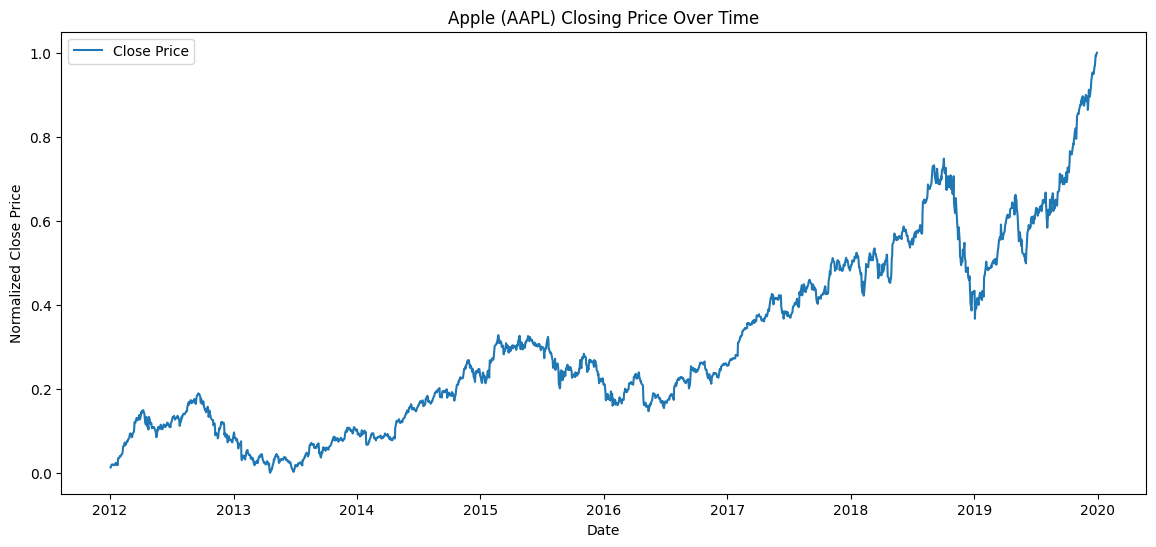

In [49]:
    #Exploratory Data Analysis********
   #Plot the Closing Price Over Time (Trend)*****

plt.figure(figsize=(14,6))
plt.plot(df.index, df['Close'], label='Close Price')
plt.title("Apple (AAPL) Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Normalized Close Price")
plt.legend()
plt.show()



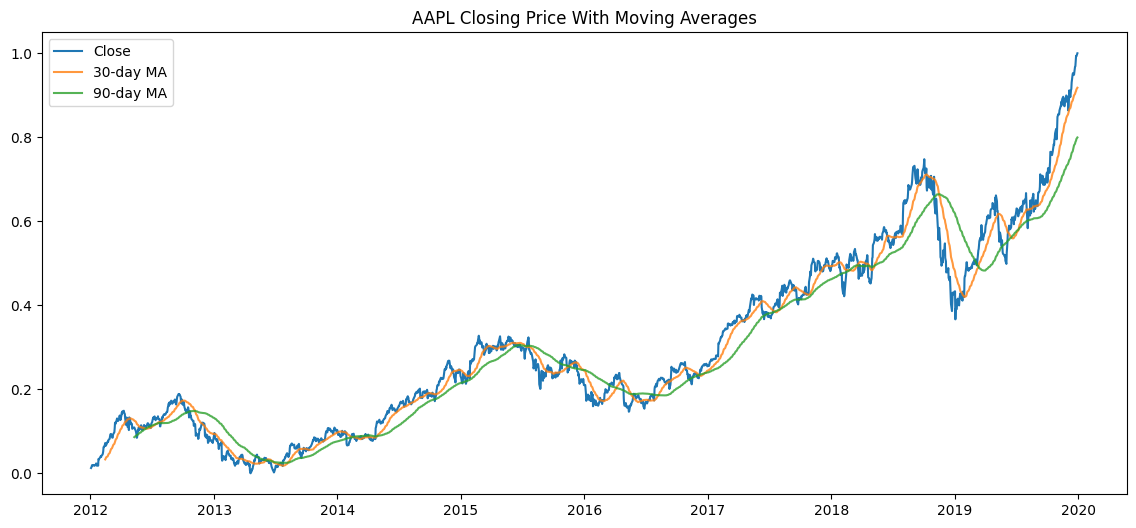

In [50]:
   # Plot Moving Averages for Trend Smoothing*****
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['Close'].rolling(window=30).mean(), label='30-day MA', alpha=0.8)
plt.plot(df['Close'].rolling(window=90).mean(), label='90-day MA', alpha=0.8)
plt.title("AAPL Closing Price With Moving Averages")
plt.legend()
plt.show()


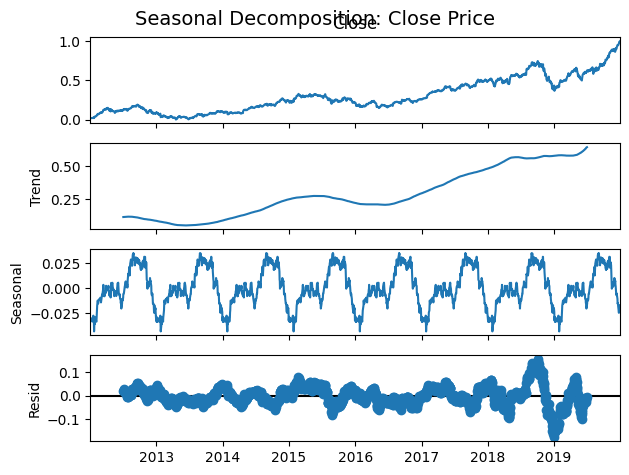

In [51]:
    #Decompose Time Series to Reveal Trend & Seasonality*******

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Close'], model='additive', period=252)  # Approx. trading days/year
decomposition.plot()
plt.suptitle("Seasonal Decomposition: Close Price", fontsize=14)
plt.show()


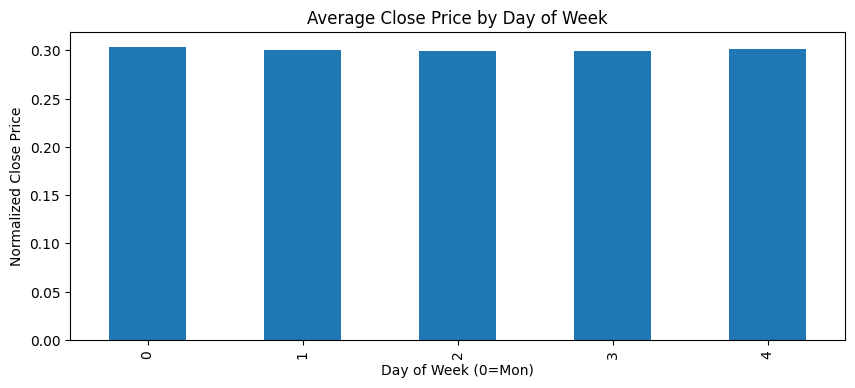

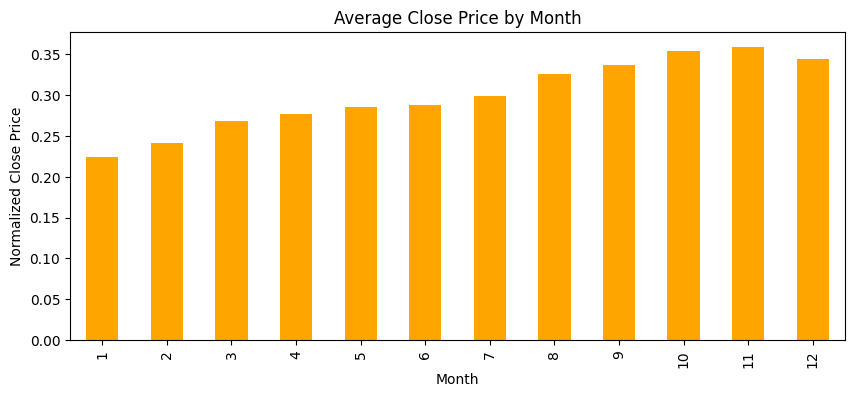

In [52]:
    #Weekly and Monthly Seasonality Patterns*****

df['DayOfWeek'] = df.index.dayofweek
df['Month'] = df.index.month

plt.figure(figsize=(10,4))
df.groupby('DayOfWeek')['Close'].mean().plot(kind='bar')
plt.title("Average Close Price by Day of Week")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Normalized Close Price")
plt.show()

plt.figure(figsize=(10,4))
df.groupby('Month')['Close'].mean().plot(kind='bar', color='orange')
plt.title("Average Close Price by Month")
plt.xlabel("Month")
plt.ylabel("Normalized Close Price")
plt.show()


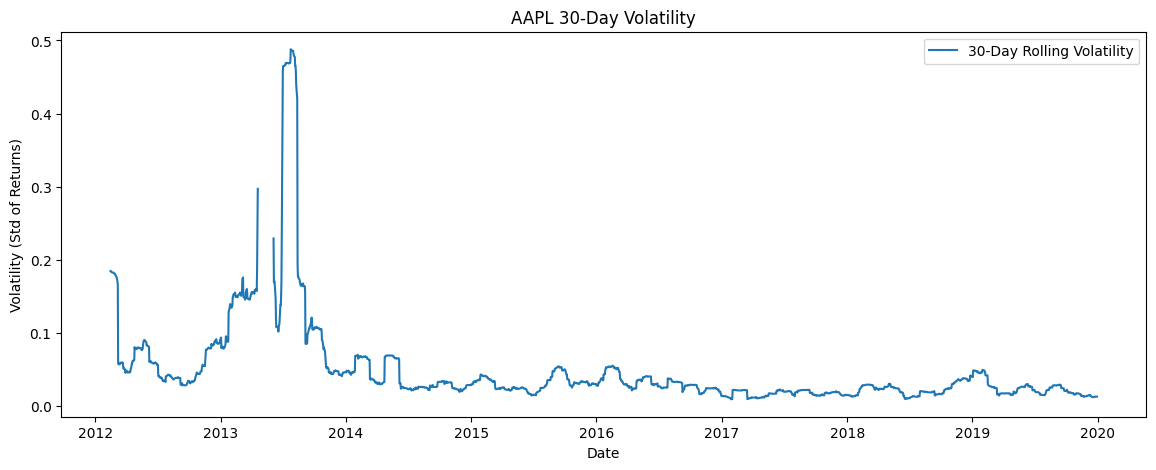

In [53]:
     #Volatility Analysis*****

df['Return'] = df['Close'].pct_change()
df['Volatility_30'] = df['Return'].rolling(window=30).std()

plt.figure(figsize=(14,5))
plt.plot(df['Volatility_30'], label='30-Day Rolling Volatility')
plt.title("AAPL 30-Day Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (Std of Returns)")
plt.legend()
plt.show()




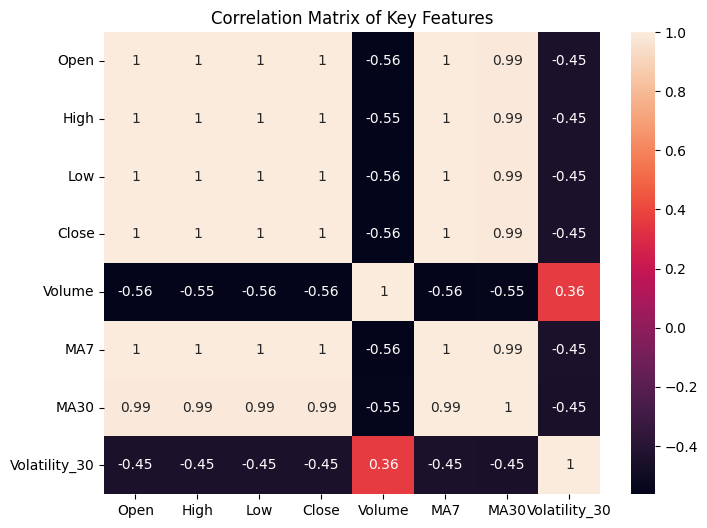

In [54]:

   #Correlation Heatmap of Features*****

plt.figure(figsize=(8,6))
sns.heatmap(df[['Open', 'High', 'Low', 'Close', 'Volume', 'MA7', 'MA30', 'Volatility_30']].corr(), annot=True)
plt.title("Correlation Matrix of Key Features")
plt.show()


# Statistical Models: ARIMA & SARIMA

In [55]:
# Import ARIMA and SARIMA models along with evaluation metrics

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np



# Split data: use all but last 30 days for training, last 30 for testing

# Fit ARIMA model (order = (5,1,0)) to capture short-term trends
# Forecast next 30 values and calculate RMSE for performance evaluation

train_arima = df['Close'][:-30]
test_arima = df['Close'][-30:]
arima_model = ARIMA(train_arima, order=(5,1,0))
arima_result = arima_model.fit()
arima_forecast = arima_result.forecast(steps=len(test_arima))
arima_rmse = np.sqrt(mean_squared_error(test_arima, arima_forecast))
print("ARIMA RMSE:", arima_rmse)


# Fit SARIMA model with seasonal component (seasonal_order = (1,0,1,12))
# Forecast next 30 values and compute RMSE
# Compare RMSE values to assess if modeling seasonality improves accuracy

sarima_model = SARIMAX(train_arima, order=(5,1,0), seasonal_order=(1,0,1,12))
sarima_result = sarima_model.fit(disp=False)
sarima_forecast = sarima_result.forecast(steps=len(test_arima))
sarima_rmse = np.sqrt(mean_squared_error(test_arima, sarima_forecast))
print("SARIMA RMSE:", sarima_rmse)

d:\Apple_stock_price_prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Apple_stock_price_prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Apple_stock_price_prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Apple_stock_price_prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index begin

ARIMA RMSE: 0.056039705616922876
SARIMA RMSE: 0.05526375456476838


d:\Apple_stock_price_prediction\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
d:\Apple_stock_price_prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\Apple_stock_price_prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [56]:
# ARIMA RMSE: 0.0560 → Good accuracy in capturing short-term trends.
# SARIMA RMSE: 0.0553 → Slightly better performance due to seasonal component.
# Conclusion: Both models performed similarly, but SARIMA provided a small improvement by accounting for seasonality.


#  Machine Learning Models: XGBoost & Random Forest

In [57]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# Prepare supervised dataset using a 30-day lookback window
# Each sample uses 30 previous closing prices to predict the next day's close
# Split data into 90% training and 10% testing sets


lookback = 30
X_ml, y_ml = [], []
close_vals = df['Close'].values
for i in range(len(close_vals) - lookback):
    X_ml.append(close_vals[i:i+lookback])
    y_ml.append(close_vals[i+lookback])
X_ml, y_ml = np.array(X_ml), np.array(y_ml)
split_ml = int(0.90 * len(X_ml))
X_train_ml, X_test_ml = X_ml[:split_ml], X_ml[split_ml:]
y_train_ml, y_test_ml = y_ml[:split_ml], y_ml[split_ml:]


# Train XGBoost Regressor (gradient boosting model)
# Predict on test data and calculate RMSE for performance evaluation
# XGBoost Model

xgb_model = XGBRegressor(n_estimators=100)
xgb_model.fit(X_train_ml, y_train_ml)
xgb_pred = xgb_model.predict(X_test_ml)
xgb_rmse = np.sqrt(mean_squared_error(y_test_ml, xgb_pred))
print("XGBoost RMSE:", xgb_rmse)


# Train Random Forest Regressor (ensemble of decision trees)
# Predict on test data and compute RMSE
# Compare RMSE values to determine which model performs better

# Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_ml, y_train_ml)
rf_pred = rf_model.predict(X_test_ml)
rf_rmse = np.sqrt(mean_squared_error(y_test_ml, rf_pred))
print("Random Forest RMSE:", rf_rmse)

XGBoost RMSE: 0.10626781065935931
Random Forest RMSE: 0.09272371307730817


In [58]:
# XGBoost RMSE: 0.1063 → Good performance with moderate prediction error.
# Random Forest RMSE: 0.0927 → Lower error, indicating better accuracy.
# Conclusion: Both models performed well, but Random Forest slightly outperformed XGBoost on this dataset.


In [59]:
print("ARIMA RMSE:", arima_rmse)
print("SARIMA RMSE:", sarima_rmse)
print("XGBoost RMSE:", xgb_rmse)
print("Random Forest RMSE:", rf_rmse)


ARIMA RMSE: 0.056039705616922876
SARIMA RMSE: 0.05526375456476838
XGBoost RMSE: 0.10626781065935931
Random Forest RMSE: 0.09272371307730817


In [60]:
# Summary:
# SARIMA had the lowest RMSE (0.0553), capturing trends and seasonality effectively.
# Random Forest was the best among ML models (RMSE: 0.0927).
# Overall, SARIMA slightly outperformed all others, showing the value of modeling seasonality.


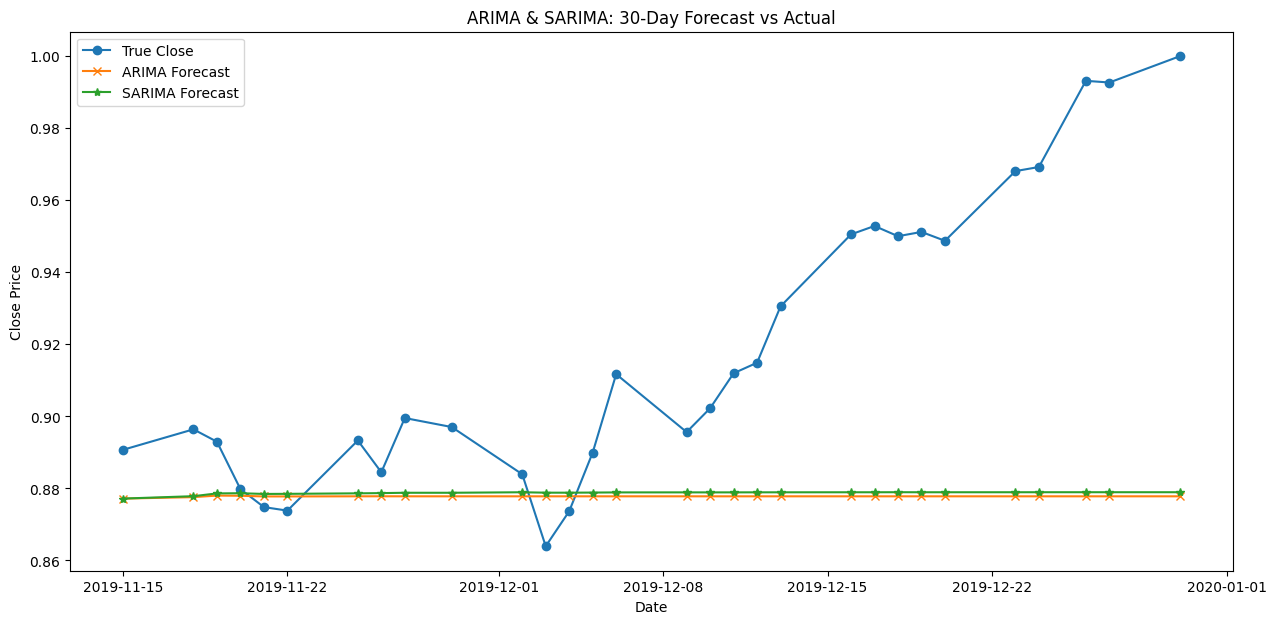

In [61]:


# Create date index for the final 30 days (test set)
test_dates = df.index[-30:]

plt.figure(figsize=(15,7))
plt.plot(test_dates, df['Close'][-30:], label='True Close', marker='o')
plt.plot(test_dates, arima_forecast, label='ARIMA Forecast', marker='x')
plt.plot(test_dates, sarima_forecast, label='SARIMA Forecast', marker='*')
plt.title('ARIMA & SARIMA: 30-Day Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()


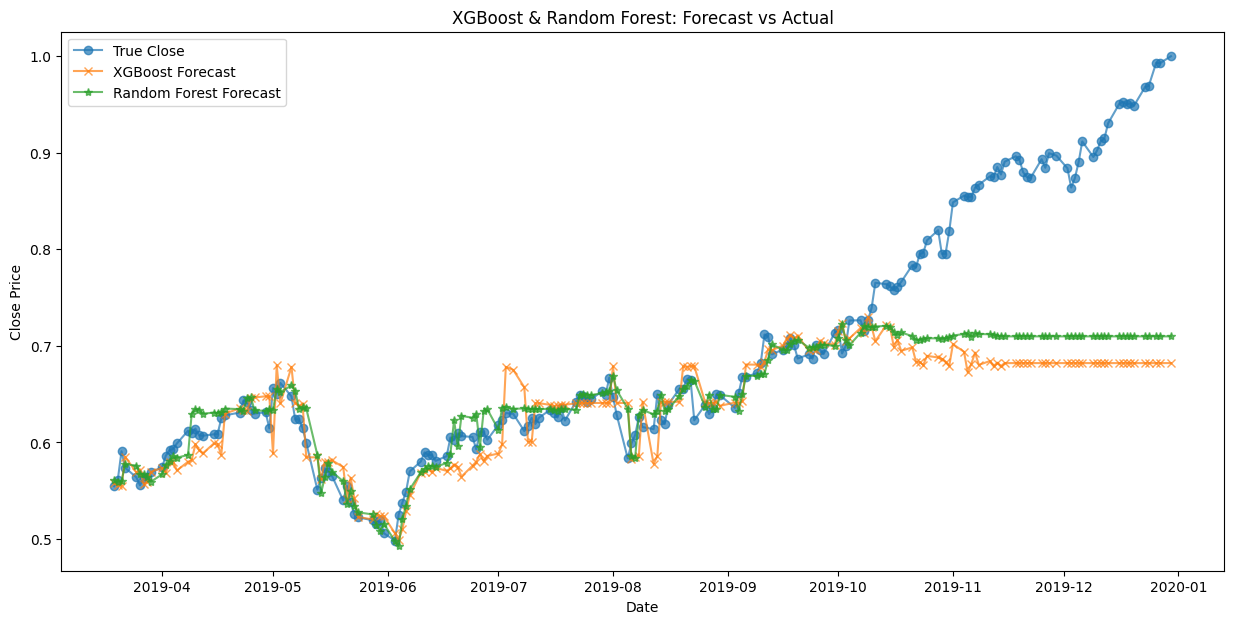

In [62]:
# Note: X_test_ml, y_test_ml correspond to test set (can be longer than 30 days)
test_len = len(y_test_ml)
ml_dates = df.index[-test_len:]

plt.figure(figsize=(15,7))
plt.plot(ml_dates, y_test_ml, label='True Close', marker='o', alpha=0.7)
plt.plot(ml_dates, xgb_pred, label='XGBoost Forecast', marker='x', alpha=0.7)
plt.plot(ml_dates, rf_pred, label='Random Forest Forecast', marker='*', alpha=0.7)
plt.title('XGBoost & Random Forest: Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()


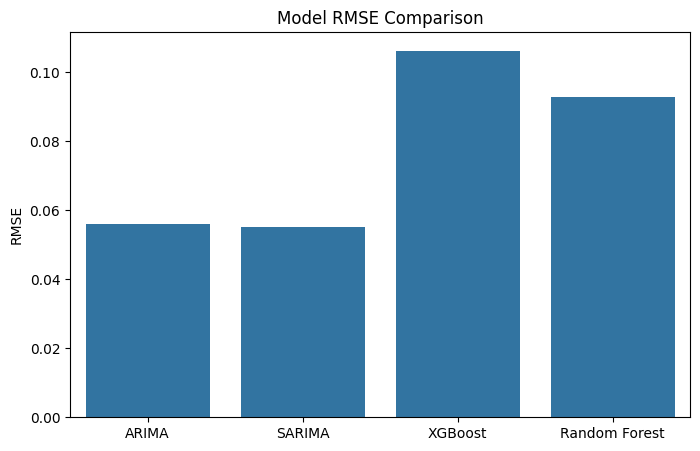

In [63]:


# Bar chart of RMSE scores for each model
models = ['ARIMA', 'SARIMA', 'XGBoost', 'Random Forest']
rmses = [arima_rmse, sarima_rmse, xgb_rmse, rf_rmse]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=rmses)
plt.title('Model RMSE Comparison')
plt.ylabel('RMSE')
plt.show()
